# DAPI Image Display Debugging

In [1]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pathlib

## Helper

In [2]:
def grayscale_to_rgb(grayscale_img):
    # Squeeze singleton dimension if present
    if grayscale_img.ndim == 3 and grayscale_img.shape[0] == 1:
        grayscale_img = np.squeeze(grayscale_img, axis=0)
    # Normalize to 0-255
    img_normalized = cv2.normalize(grayscale_img, None, 0, 255, cv2.NORM_MINMAX)
    img_normalized = img_normalized.astype(np.uint8)
    img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
    return img_rgb

In [3]:
# clip outliers before noramlization
def remove_outliers(img, k=18.0, use_median=False):
    """
    Clip values that are more than k std-dev (or MAD units) above center.
    Args:
        img: 16-bit numpy array
        k: threshold (e.g. 3σ)
        use_median: if True use median+MAD, else mean+std
    Returns:
        clipped float32 image in [0,1]
    """

    print("OUTLIERS REMOVING...")
    x = img.astype(np.float32)

    if use_median:
        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-6
        sigma = 1.4826 * mad  # robust std estimate
        thresh = med + k * sigma
    else:
        mean = np.mean(x)
        std = np.std(x)
        thresh = mean + k * std

    # clip outliers
    x_clipped = np.minimum(x, thresh)

    # normalize after clipping (to 0..1)
    x_norm = (x_clipped - x_clipped.min()) / (x_clipped.max() - x_clipped.min() + 1e-6)
    return x_norm

## Understanding Issues

In [4]:
single_DAPI = pathlib.Path(r'C:\Users\Hong\FISH-ML2\assets\testing_dapi\MAX_KD1_w1-358 DAPI_s000.tif') 
zprojected_DAPI = pathlib.Path(r'C:\Users\Hong\FISH-ML2\assets\testing_dapi\MAX_KD1_w1-358 reDAPI_s000.tif')
problematic_DAPI = pathlib.Path(r'C:\Users\Hong\FISH-ML2\assets\testing_dapi\MAX_KD1_w1-358 reDAPI_s001.tif')

single_pil = Image.open(single_DAPI)
zprojected_pil = Image.open(zprojected_DAPI)
problematic_pil = Image.open(problematic_DAPI)

single_np = np.array(single_pil)
print('Loaded image shape:', single_np.shape, 'dtype:', single_np.dtype, 'min:', single_np.min(), 'max:', single_np.max())
zprojected_np = np.array(zprojected_pil)
print('Loaded image shape:', zprojected_np.shape, 'dtype:', zprojected_np.dtype, 'min:', zprojected_np.min(), 'max:', zprojected_np.max())
problematic_np = np.array(problematic_pil)
print('Loaded image shape:', problematic_np.shape, 'dtype:', problematic_np.dtype, 'min:', problematic_np.min(), 'max:', problematic_np.max())


Loaded image shape: (2048, 2048) dtype: uint16 min: 59 max: 4889
Loaded image shape: (2048, 2048) dtype: uint16 min: 100 max: 6144
Loaded image shape: (2048, 2048) dtype: >u2 min: 100 max: 6144


>u2 where > means big endian while u2 means unsigned 2 byte integer which is equivalent to unit16 where pixel values range from 0 to 65535
min 100 means the darkest while the max value of 6144 is the brightest pixel value

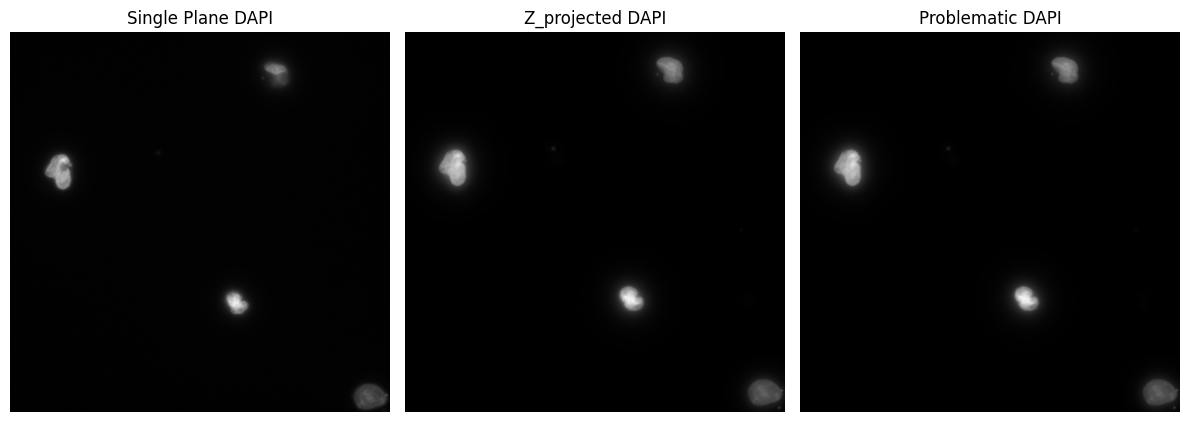

In [5]:
# Display in graysscale

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(single_np, cmap='gray')
axes[0].set_title('Single Plane DAPI')
axes[0].axis('off')

axes[1].imshow(zprojected_np, cmap='gray')
axes[1].set_title('Z_projected DAPI')
axes[1].axis('off')

axes[2].imshow(problematic_np, cmap='gray')
axes[2].set_title('Problematic DAPI')
axes[2].axis('off')

plt.tight_layout()
plt.show()


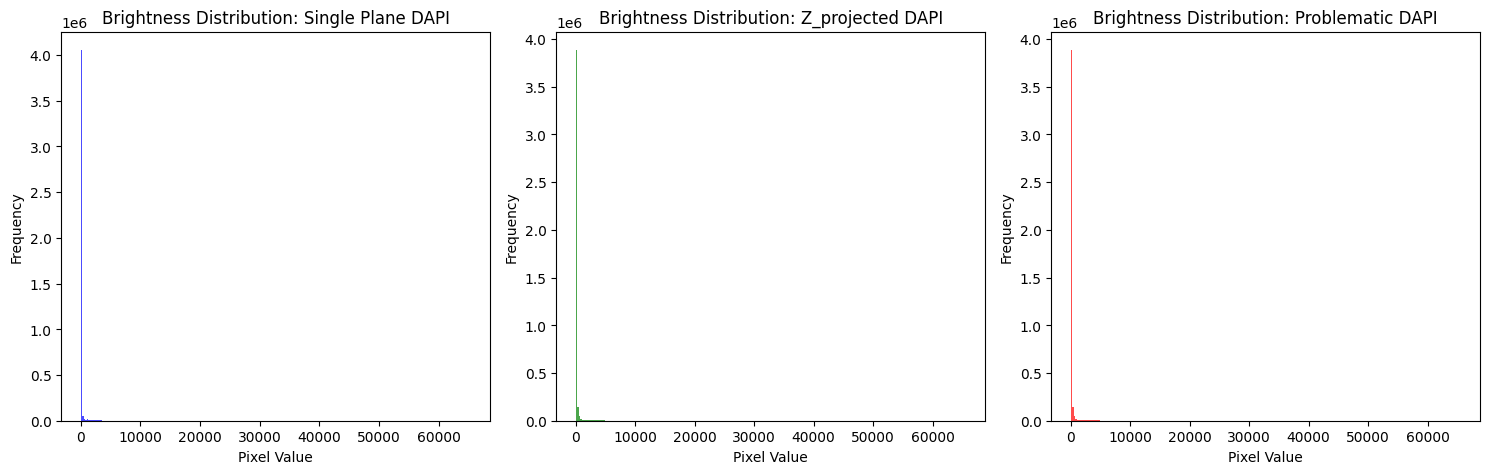

In [ ]:
# comparing brightness distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram for single_np
axes[0].hist(single_np.flatten(), bins=256, range=(0, 65355), color='blue', alpha=0.7)
axes[0].set_title('Brightness Distribution: Single Plane DAPI')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')

# Histogram for zprojected_np
axes[1].hist(zprojected_np.flatten(), bins=256, range=(0, 65535), color='green', alpha=0.7)
axes[1].set_title('Brightness Distribution: Z_projected DAPI')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')

# Histogram for problematic_np
axes[2].hist(problematic_np.flatten(), bins=256, range=(0, 65535), color='red', alpha=0.7)
axes[2].set_title('Brightness Distribution: Problematic DAPI')
axes[2].set_xlabel('Pixel Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

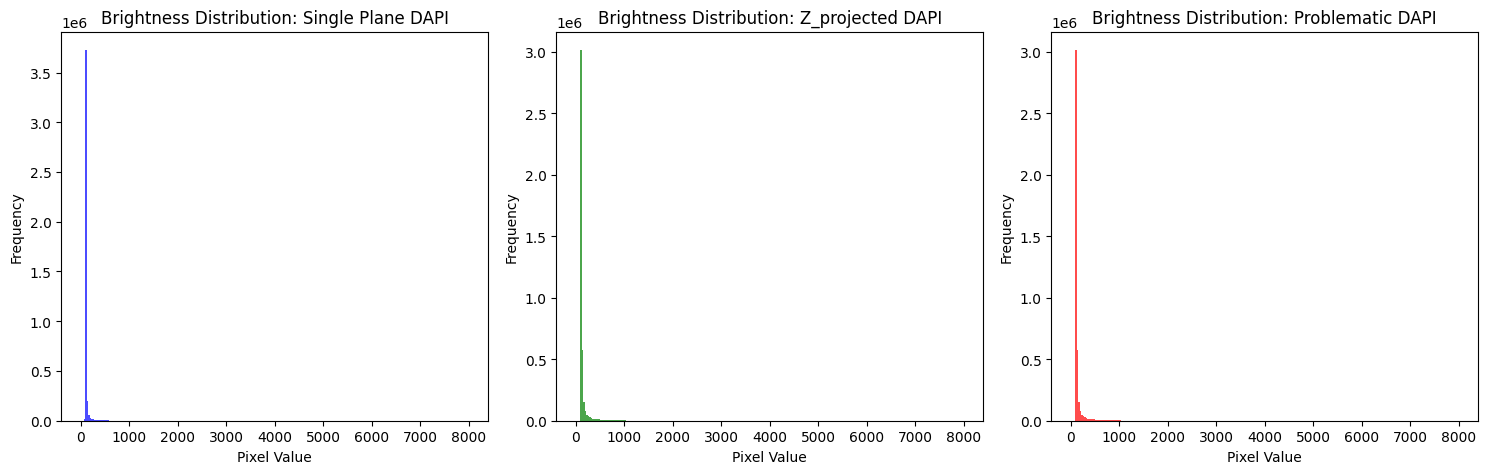

In [8]:
# comparing brightness distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram for single_np
axes[0].hist(single_np.flatten(), bins=256, range=(0, 8000), color='blue', alpha=0.7)
axes[0].set_title('Brightness Distribution: Single Plane DAPI')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')

# Histogram for zprojected_np
axes[1].hist(zprojected_np.flatten(), bins=256, range=(0, 8000), color='green', alpha=0.7)
axes[1].set_title('Brightness Distribution: Z_projected DAPI')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')

# Histogram for problematic_np
axes[2].hist(problematic_np.flatten(), bins=256, range=(0, 8000), color='red', alpha=0.7)
axes[2].set_title('Brightness Distribution: Problematic DAPI')
axes[2].set_xlabel('Pixel Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

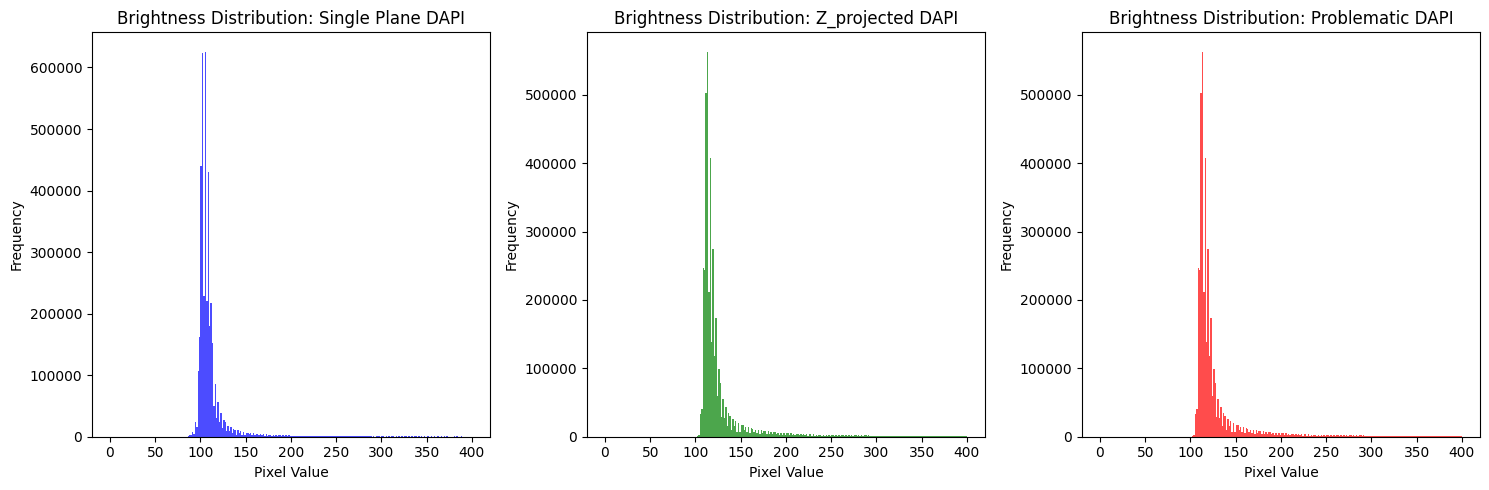

In [11]:
# comparing brightness distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram for single_np
axes[0].hist(single_np.flatten(), bins=256, range=(0, 400), color='blue', alpha=0.7)
axes[0].set_title('Brightness Distribution: Single Plane DAPI')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')

# Histogram for zprojected_np
axes[1].hist(zprojected_np.flatten(), bins=256, range=(0, 400), color='green', alpha=0.7)
axes[1].set_title('Brightness Distribution: Z_projected DAPI')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')

# Histogram for problematic_np
axes[2].hist(problematic_np.flatten(), bins=256, range=(0, 400), color='red', alpha=0.7)
axes[2].set_title('Brightness Distribution: Problematic DAPI')
axes[2].set_xlabel('Pixel Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

larger range with 256 buckets, means most pixels pile up in just a few buckets, making the frequency high. smaller range with 256 buckets, means the pixels are spread out more evenly across more buckets, so the frequency for each pixel value decreases

distribution between s000 reDAPI and s001 reDAPI seems to be the same. Why would it work for s000 while we have to clip outliers for s001?

In [12]:
# Compare distributions before any swapping/processing
print("Stats for zprojected_np (s000, uint16):")
print(f"  Min: {zprojected_np.min()}, Max: {zprojected_np.max()}, Mean: {zprojected_np.mean():.2f}, Std: {zprojected_np.std():.2f}")

print("Stats for problematic_np (s001, >u2 - misinterpreted):")
print(f"  Min: {problematic_np.min()}, Max: {problematic_np.max()}, Mean: {problematic_np.mean():.2f}, Std: {problematic_np.std():.2f}")

Stats for zprojected_np (s000, uint16):
  Min: 100, Max: 6144, Mean: 195.34, Std: 412.08
Stats for problematic_np (s001, >u2 - misinterpreted):
  Min: 100, Max: 6144, Mean: 195.34, Std: 412.08


Seems like the distributions is similar. So it is wierd that we only have to clip the third one. Would this mean that the issue isn't necessarily because of outliers in brightness, but a image format issue? >u2 vs unit16?

Convert from >u2 to unit16 --
big endian to little endian --
big endian may have caused extreme values that resulted in blobs

In [ ]:
# Reload for fresh state
problematic_np = np.array(Image.open(r'C:\Users\Hong\FISH-ML2\assets\testing_dapi\MAX_KD1_w1-358 reDAPI_s001.tif'))

print("Dtype before:", problematic_np.dtype)

# Inspect raw bytes before byteswap
print("Before byteswap (big-endian >u2):")
print("First 10 bytes (hex):", problematic_np.tobytes()[:10].hex())
print("Last 10 bytes (hex):", problematic_np.tobytes()[-10:].hex())
print("First pixel value:", problematic_np.flat[0], "as bytes:", int(problematic_np.flat[0]).to_bytes(2, byteorder='big'))

# Apply byteswap
if problematic_np.dtype == '>u2':
    problematic_np = problematic_np.byteswap(inplace=True).astype(np.uint16)
    print("Byteswap applied.")
else:
    print("Byteswap skipped (dtype not >u2).")

print("Dtype after:", problematic_np.dtype)

# Inspect raw bytes after byteswap
print("\nAfter byteswap (little-endian uint16):")
print("First 10 bytes (hex):", problematic_np.tobytes()[:10].hex())
print("Last 10 bytes (hex):", problematic_np.tobytes()[-10:].hex())
print("First pixel value:", problematic_np.flat[0], "as bytes:", int(problematic_np.flat[0]).to_bytes(2, byteorder='little'))

In [ ]:
problematic_np = np.array(problematic_pil)
if problematic_np.dtype == '>u2':
    problematic_little_np = problematic_np.byteswap(inplace=True).astype(np.uint16)
problematic_little_np = remove_outliers(problematic_np, k=18.0, use_median=False)
print('Loaded image shape:', problematic_np.shape, 'dtype:', problematic_np.dtype, 'min:', problematic_np.min(), 'max:', problematic_np.max())
print('Loaded image shape:', problematic_little_np.shape, 'dtype:', problematic_little_np.dtype, 'min:', problematic_little_np.min(), 'max:', problematic_little_np.max())

In [ ]:
problematic_clipped = remove_outliers(problematic_np, k=18.0, use_median=False)
problematic_little_clipped = remove_outliers(problematic_little_np, k=18.0, use_median=False)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
single_rgb = grayscale_to_rgb(single_np)
zprojected_rgb = grayscale_to_rgb(zprojected_np)
problematic_rgb = grayscale_to_rgb(problematic_np)
problematic_little_rgb = grayscale_to_rgb(problematic_little_np)

axes[0].imshow(single_rgb)
axes[0].set_title('Single Plane DAPI')
axes[0].axis('off')

axes[1].imshow(zprojected_rgb)
axes[1].set_title('Z_projected DAPI')
axes[1].axis('off')

axes[2].imshow(problematic_rgb)
axes[2].set_title('Problematic DAPI')
axes[2].axis('off')

axes[3].imshow(problematic_little_rgb)
axes[3].set_title('Problematic DAPI')
axes[3].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
print('Loaded image shape:', single_rgb.shape, 'dtype:', single_rgb.dtype, 'min:', single_rgb.min(), 'max:', single_rgb.max())
print('Loaded image shape:', zprojected_rgb.shape, 'dtype:', zprojected_rgb.dtype, 'min:', zprojected_rgb.min(), 'max:', zprojected_rgb.max())
print('Loaded image shape:', problematic_rgb.shape, 'dtype:', problematic_rgb.dtype, 'min:', problematic_rgb.min(), 'max:', problematic_rgb.max())
print('Loaded image shape:', problematic_little_rgb.shape, 'dtype:', problematic_little_rgb.dtype, 'min:', problematic_little_rgb.min(), 'max:', problematic_little_rgb.max())

try each step one at a time
        img_normalized = cv2.normalize(grayscale_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
        brightness_factor = 1
        return np.clip(img_rgb * brightness_factor, 0, 255).astype(np.uint8)

In [ ]:
single_normalized = cv2.normalize(single_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
zprojected_normalized = cv2.normalize(zprojected_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
problematic_normalized = cv2.normalize(problematic_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
problematic_little_normalized = cv2.normalize(problematic_little_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print('Loaded image shape:', single_normalized.shape, 'dtype:', single_normalized.dtype, 'min:', single_normalized.min(), 'max:', single_normalized.max())
print('Loaded image shape:', zprojected_normalized.shape, 'dtype:', zprojected_normalized.dtype, 'min:', zprojected_normalized.min(), 'max:', zprojected_normalized.max())
print('Loaded image shape:', problematic_normalized.shape, 'dtype:', problematic_normalized.dtype, 'min:', problematic_normalized.min(), 'max:', problematic_normalized.max())
print('Loaded image shape:', problematic_little_normalized.shape, 'dtype:', problematic_little_normalized.dtype, 'min:', problematic_little_normalized.min(), 'max:', problematic_little_normalized.max())

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
axes[0].imshow(single_normalized, cmap='gray')
axes[0].set_title('Single Plane DAPI')
axes[0].axis('off')

axes[1].imshow(zprojected_normalized, cmap='gray')
axes[1].set_title('Z_projected DAPI')
axes[1].axis('off')

axes[2].imshow(problematic_normalized, cmap='gray')
axes[2].set_title('Problematic DAPI')
axes[2].axis('off')

axes[3].imshow(problematic_little_normalized, cmap='gray')
axes[3].set_title('Problematic DAPI')
axes[3].axis('off')

plt.tight_layout()
plt.show()


Seems like the issue occurs after normalization

In [ ]:
import matplotlib.pyplot as plt
plt.hist(problematic_normalized.flatten(), bins=256)
plt.show()

In [ ]:
single_normalized = cv2.normalize(single_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
zprojected_normalized = cv2.normalize(zprojected_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
problematic_normalized = cv2.normalize(problematic_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print('Loaded image shape:', single_normalized.shape, 'dtype:', single_normalized.dtype, 'min:', single_normalized.min(), 'max:', single_normalized.max())
print('Loaded image shape:', zprojected_normalized.shape, 'dtype:', zprojected_normalized.dtype, 'min:', zprojected_normalized.min(), 'max:', zprojected_normalized.max())
print('Loaded image shape:', problematic_normalized.shape, 'dtype:', problematic_normalized.dtype, 'min:', problematic_normalized.min(), 'max:', problematic_normalized.max())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(single_normalized, cmap='gray')
axes[0].set_title('Single Plane DAPI')
axes[0].axis('off')

axes[1].imshow(zprojected_normalized, cmap='gray')
axes[1].set_title('Z_projected DAPI')
axes[1].axis('off')

axes[2].imshow(problematic_normalized, cmap='gray')
axes[2].set_title('Problematic DAPI')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Worked! Issue solved 
Issue : extreme outliers caused the blob for some reason

In [ ]:
single_step_rgb = cv2.cvtColor(single_normalized, cv2.COLOR_GRAY2RGB)
zprojected_step_rgb = cv2.cvtColor(zprojected_normalized, cv2.COLOR_GRAY2RGB)
problematic_step_rgb = cv2.cvtColor(problematic_normalized, cv2.COLOR_GRAY2RGB)

print('Loaded image shape:', single_step_rgb.shape, 'dtype:', single_step_rgb.dtype, 'min:', single_step_rgb.min(), 'max:', single_step_rgb.max())
print('Loaded image shape:', zprojected_step_rgb.shape, 'dtype:', zprojected_step_rgb.dtype, 'min:', zprojected_step_rgb.min(), 'max:', zprojected_step_rgb.max())
print('Loaded image shape:', problematic_step_rgb.shape, 'dtype:', problematic_step_rgb.dtype, 'min:', problematic_step_rgb.min(), 'max:', problematic_step_rgb.max())